# Exercises in statistics

In [84]:
import pandas
import seaborn
import matplotlib.pyplot as plot
import scipy.stats as stats
import numpy

In [85]:
pandas.set_option("display.max_columns", 100)
pandas.set_option("display.width", 140)

plot.rcParams["figure.figsize"] = (8, 4)
plot.rcParams["axes.grid"] = True

## Exercise 1

In this exercise we will use the penguins dataset (can be imported using the code `penguins_data = sns.load_dataset("penguins")`)

Please answer the following questions:
1. For the different species of penguins (Adelie, Chinstrap, and Gentoo), how many penguins are there of each species?
2. For the different species of penguins (Adelie, Chinstrap, and Gentoo), is the body mass variable normally distributed?
3. Test whether there is a difference in body mass for Adelie penguins and Chinstrap penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.
4. Test whether there is a difference in body mass for Chinstrap penguins and Gentoo penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.

In [86]:
penguins_dataframe = seaborn.load_dataset("penguins").copy()

### 0. What does the dataset look like? (columns, types, missing values, duplicates)

In [87]:
print("Dataset shape:", penguins_dataframe.shape)
display(penguins_dataframe)

Dataset shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [88]:
print("Columns:")
print(list(penguins_dataframe.columns))


Columns:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


In [89]:
print("\nData types:")
print(penguins_dataframe.dtypes)


Data types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


In [90]:
missing_value_counts = penguins_dataframe.isna().sum().sort_values(ascending=False)
missing_value_percentages = (missing_value_counts / len(penguins_dataframe) * 100).round(2)

missing_value_report = pandas.DataFrame(
    {
        "missing_count": missing_value_counts,
        "missing_pct": missing_value_percentages
    }
)
display(missing_value_report[missing_value_report["missing_count"] > 0])

,missing_count,missing_pct
sex,11,3.20
bill_depth_mm,2,0.58
bill_length_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58


### 1. For the different species of penguins (Adelie, Chinstrap, and Gentoo), how many penguins are there of each species?

Penguins per species


,count
species,
Adelie,152
Chinstrap,68
Gentoo,124


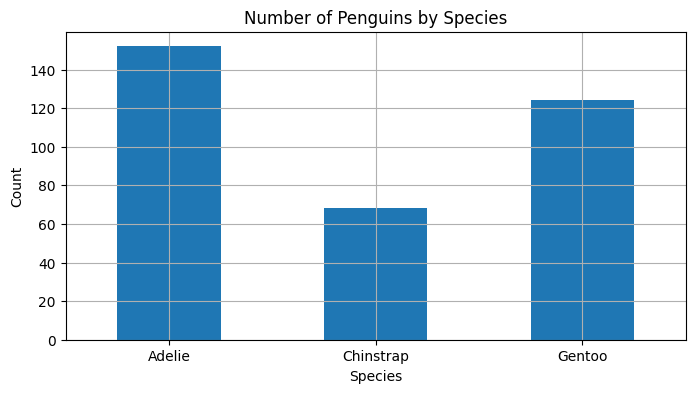

In [91]:
species_count_series = penguins_dataframe["species"].value_counts(dropna=False).sort_index()
species_count_dataframe = species_count_series.to_frame(name="count")

print("Penguins per species")
display(species_count_dataframe)

species_count_axis = species_count_series.plot(kind="bar", rot=0)
species_count_axis.set_title("Number of Penguins by Species")
species_count_axis.set_xlabel("Species")
species_count_axis.set_ylabel("Count")
plot.show()



### 2. For the different species of penguins (Adelie, Chinstrap, and Gentoo), is the body mass variable normally distributed?

Yes they are.

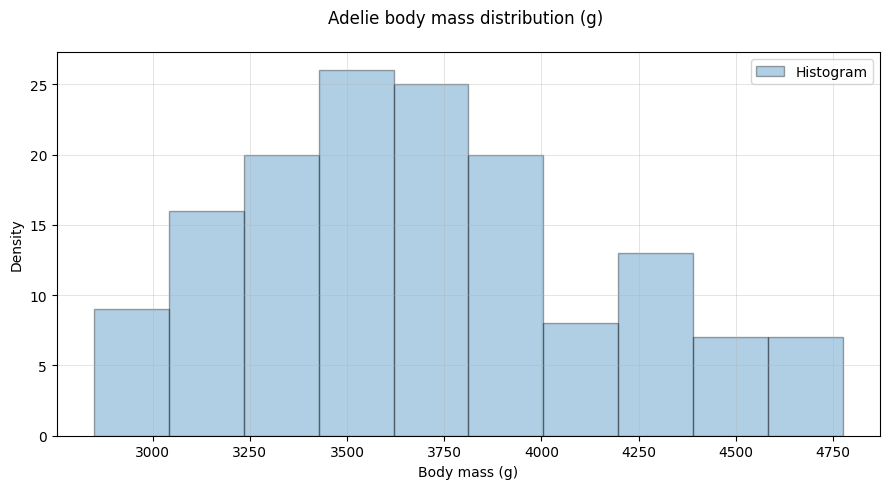

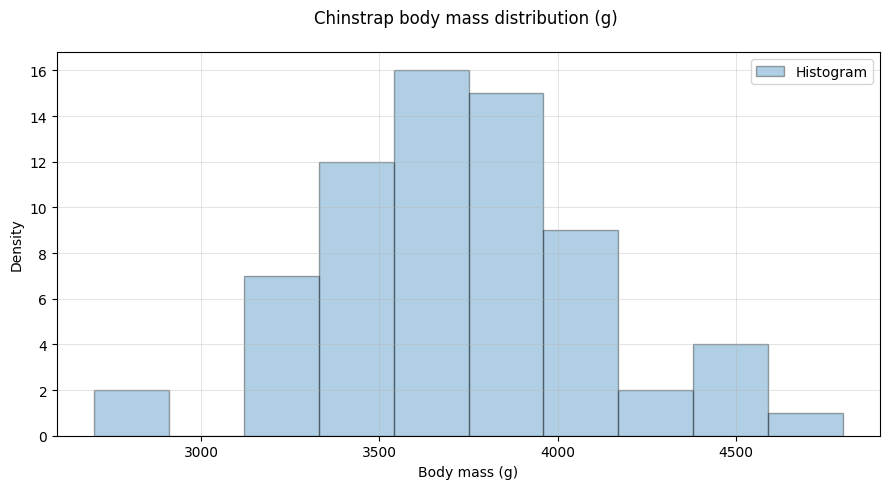

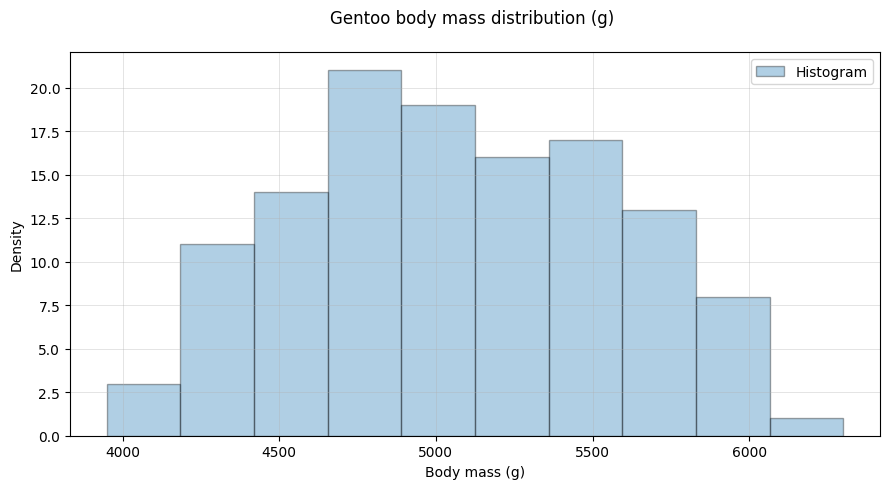

In [92]:
species_order = ["Adelie", "Chinstrap", "Gentoo"]

for species_name in species_order:
    x = (
        penguins_dataframe.loc[penguins_dataframe["species"] == species_name, "body_mass_g"]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    figure, axis = plot.subplots(figsize=(9, 5))

    axis.hist(x, alpha=0.35, edgecolor="black", label="Histogram")

    axis.set_title(f"{species_name} body mass distribution (g) \n")
    axis.set_xlabel("Body mass (g)")
    axis.set_ylabel("Density")
    axis.grid(True, linewidth=0.4, alpha=0.6)
    axis.legend()

    plot.tight_layout()
    plot.show()

### 3. Test whether there is a difference in body mass for Adelie penguins and Chinstrap penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.

In [93]:
import numpy as np

adelie_body_mass = (
    penguins_dataframe.loc[
        penguins_dataframe["species"] == "Adelie",
        "body_mass_g",
    ]
    .dropna()
    .astype(float)
    .to_numpy()
)

chinstrap_body_mass = (
    penguins_dataframe.loc[
        penguins_dataframe["species"] == "Chinstrap",
        "body_mass_g",
    ]
    .dropna()
    .astype(float)
    .to_numpy()
)

adelie_std = np.std(adelie_body_mass, ddof=1)
chinstrap_std = np.std(chinstrap_body_mass, ddof=1)

print(f"Adelie sample size: {adelie_body_mass.size}")
print(f"Chinstrap sample size: {chinstrap_body_mass.size}")
print(f"Adelie mean body mass: {adelie_body_mass.mean():.2f} g")
print(f"Chinstrap mean body mass: {chinstrap_body_mass.mean():.2f} g")
print(f"Body mass mean difference: {abs(adelie_body_mass.mean() - chinstrap_body_mass.mean()):.2f} g")
print(f"Adelie standard deviation: {adelie_std:.2f} g")
print(f"Chinstrap standard deviation: {chinstrap_std:.2f} g")
print(f"Standard deviation difference: {abs(adelie_std - chinstrap_std):.2f} g")

Adelie sample size: 151
Chinstrap sample size: 68
Adelie mean body mass: 3700.66 g
Chinstrap mean body mass: 3733.09 g
Body mass mean difference: 32.43 g
Adelie standard deviation: 458.57 g
Chinstrap standard deviation: 384.34 g
Standard deviation difference: 74.23 g


#### Hypotheses

Let:

$\mu_A$ = mean body mass of Adelie penguins

$\mu_C$ = mean body mass of Chinstrap penguins

Then:

Null hypothesis ($H_0$): there is no difference in mean body mass between Adelie and Chinstrap penguins

$H_0: \mu_A = \mu_C$

Alternative hypothesis ($H_1$): there is a difference in mean body mass between Adelie and Chinstrap penguins

$H_1: \mu_A \ne \mu_C$

This is a two-sided test because the question asks whether there is a difference, not whether one group is specifically larger than the other.

#### Data structure

The samples are two separate groups, not paired observations.

The response variable, body mass, is continuous.

#### Assumptions

The data in each group is assumed to be approximately normally distributed.

The two groups are treated as independent.

#### Choice of test

A Student’s t-test is my choice.

I read a study suggesting Welch T-Test as the better default, because it does not require equal variances.

So i will try to compare the two.

In [94]:
#students t-test

from scipy import stats

alpha_significance_level = 0.05

test_result = stats.ttest_ind(
    adelie_body_mass,
    chinstrap_body_mass,
    equal_var=True,  # Student's two-sample t-test
)

p_value = float(test_result.pvalue)

print(f"p-value: {p_value:.6f}")

if p_value < alpha_significance_level:
    print("Reject H0: there is a statistically significant difference in mean body mass.")
else:
    print("Fail to reject H0: there is not enough evidence of a statistically significant difference in mean body mass.")

p-value: 0.611908
Fail to reject H0: there is not enough evidence of a statistically significant difference in mean body mass.


In [95]:
#welch t-test

import numpy as np
from scipy import stats

alpha = 0.05

test_result = stats.ttest_ind(
    adelie_body_mass,
    chinstrap_body_mass,
    equal_var=False,  # Welch t-test
)

p_value = float(test_result.pvalue)

print(f"p-value: {p_value:.6f}")

if p_value < alpha:
    print("Reject H0: there is a statistically significant difference in mean body mass.")
else:
    print("Fail to reject H0: there is not enough evidence of a statistically significant difference in mean body mass.")

p-value: 0.587861
Fail to reject H0: there is not enough evidence of a statistically significant difference in mean body mass.


With $p = 0.587861$, i do **not reject** $H_0$ at $\alpha = 0.05$.

The rule is:

- if **p-value < $\alpha$** $\rightarrow$ reject $H_0$
- if **p-value $\geq \alpha$** $\rightarrow$ fail to reject $H_0$

Here I have:

- $p = 0.587861$
- $\alpha = 0.05$

Since:

- $0.587861 > 0.05$

I **fail to reject the null hypothesis**.

##### Why this makes sense here

The sample means are:

Adelie: 3700.66 g

Chinstrap: 3733.09 g

Difference:

3733.09 − 3700.66 = 32.43 g

That is a very small difference relative to the group standard deviations, which were in the hundreds of grams. So a non-significant result is not surprising.

### 4. Test whether there is a difference in body mass for Chinstrap penguins and Gentoo penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.

## Exercise 2

Load in the "fb_like_and_share.csv" data and answer the following questions:

1. Is there a difference in the distribution of likes for photos and videos? Justify your choice of test(s).
2. Is there a difference in the distribution of share counts for photos and videos? Justify your choice of test(s).
3. Perform an ANOVA test to test if there is a difference in means across type of posts for shares. Does it make sense to perform this ANOVA test?
4. Is there actually a statistical significant difference in the distribution of share counts for any two groups?

## Exercise 3

Load in the data "energySoftware.csv" and answer the following questions:
1. Plot the distribution of CPU for each test type
2. Is there a difference in the CPU between bubblesort and bubblesort_ll? (note that the last name contains two small l's and not two capital i's) Justify your choice of test(s). 
3. Is there a difference in the CPU between bubblesort_func and bubblesort_ll2? Justify your choice of test(s). If there is a difference, how big is it?
4. When it comes to time, is there a difference between bubblesort and bubblesort_ll? Justify your choice of test(s).
5. Perform an ANOVA test to test if there is a difference in means across groups for time